#importing libraries

In [2]:
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Task 1: Dataset Exploration

#Extracting dataset

In [3]:
zip_file = "banknote+authentication.zip"
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()
print(os.listdir())

['banknote+authentication.zip', 'Bias_Evolution.png', 'Boxplots.png', 'Confusion_Matrix.png', 'Correlation_Heatmap.png', 'data_banknote_authentication.txt', 'Experiment_1.ipynb', 'Experiment_1.tex', 'Experiment_1_Lab_Manual.pdf', 'Guidelines_CS3807.pdf', 'Histograms.png', 'Learning_Rate_Comparison.png', 'Scatter_Plots.png', 'Training_Error.png', 'Weight_Evolution.png']


#Naming dataset and displaying head

In [4]:
columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

dataset = pd.read_csv("data_banknote_authentication.txt", header= None, names=columns)

dataset.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


#Dataset Dimensions

In [5]:

print("Dataset Dimensions:", dataset.shape)

Dataset Dimensions: (1372, 5)


#Missing values

In [6]:
print("Missing Values in Each Column:")
print(dataset.isnull().sum())

Missing Values in Each Column:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


#Descriptive Statistics

In [7]:
print(dataset.describe())

          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


# Task 2: Exploratory Data Analysis

#Histograms

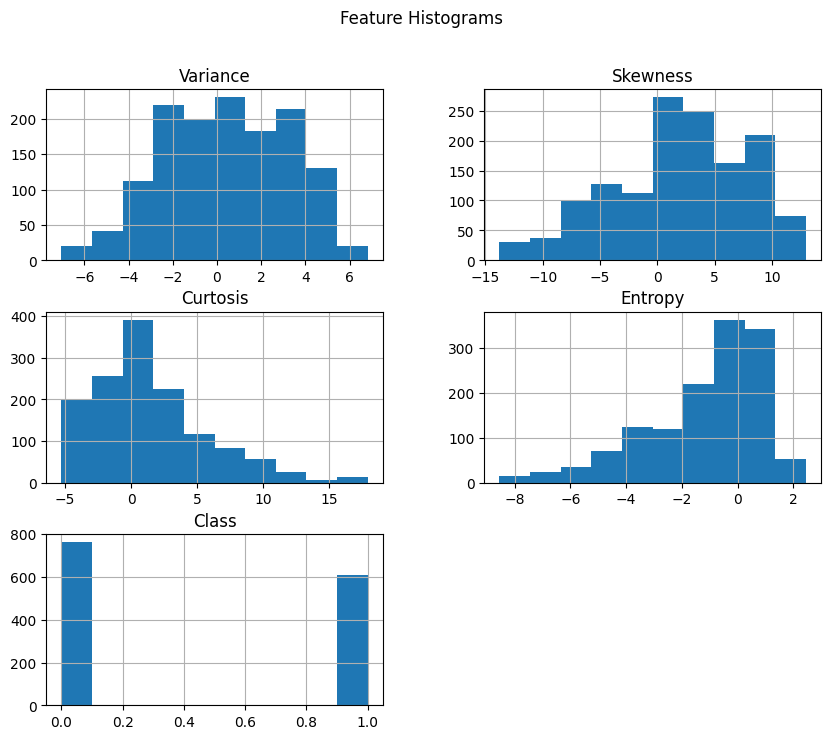

In [8]:
# Histograms
dataset.hist(figsize=(10,8))
plt.suptitle("Feature Histograms")

plt.savefig("Histograms.png", dpi=300, bbox_inches="tight")

plt.show()

#Correlation Heatmap

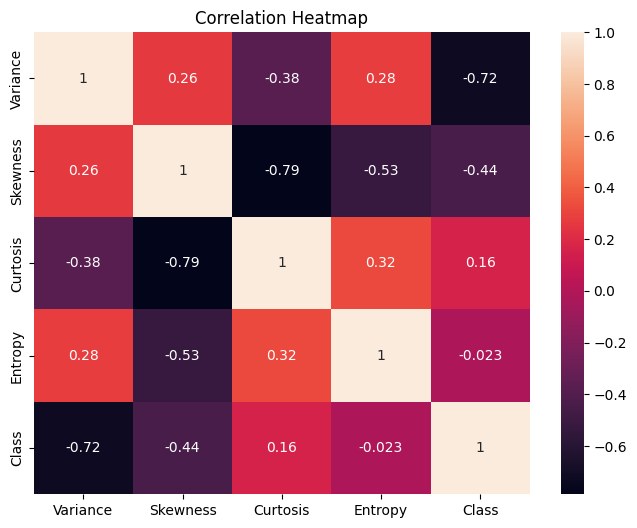

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(dataset.corr(), annot=True)
plt.title("Correlation Heatmap")

plt.savefig("Correlation_Heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

#Scatter Plots

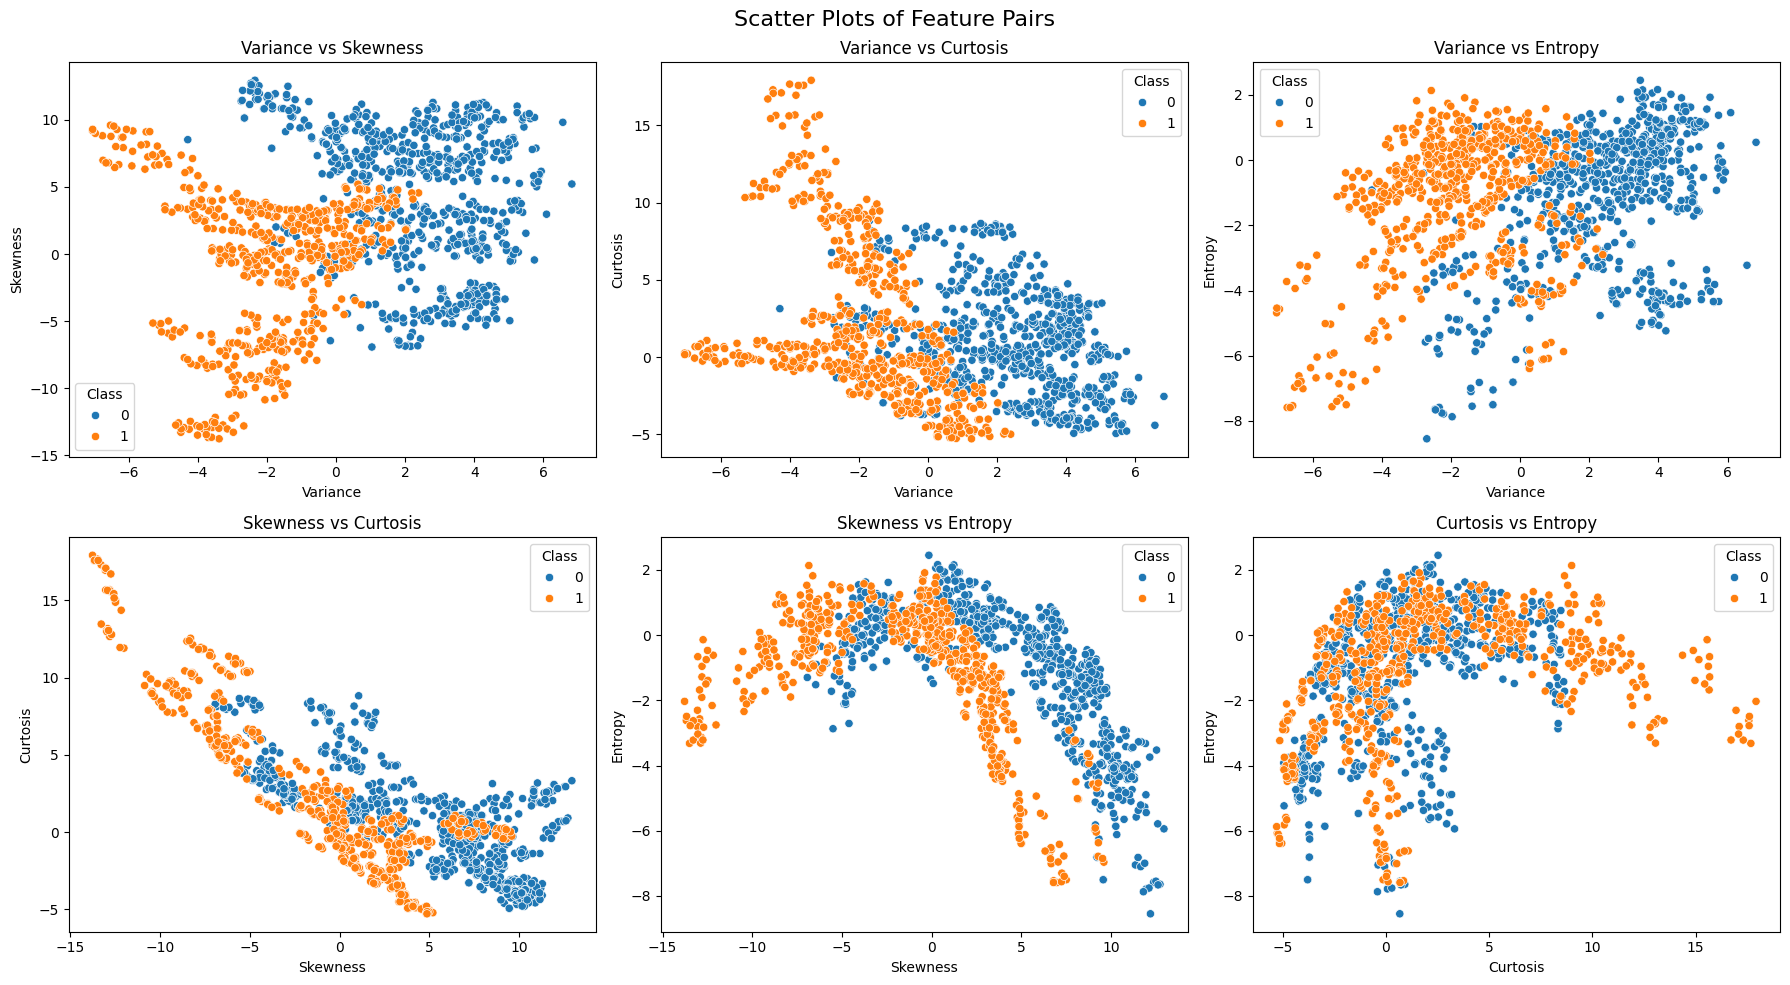

In [10]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.scatterplot(data=dataset, x="Variance", y="Skewness", hue="Class", ax=axes[0,0])
axes[0,0].set_title("Variance vs Skewness")

sns.scatterplot(data=dataset, x="Variance", y="Curtosis", hue="Class", ax=axes[0,1])
axes[0,1].set_title("Variance vs Curtosis")

sns.scatterplot(data=dataset, x="Variance", y="Entropy", hue="Class", ax=axes[0,2])
axes[0,2].set_title("Variance vs Entropy")

sns.scatterplot(data=dataset, x="Skewness", y="Curtosis", hue="Class", ax=axes[1,0])
axes[1,0].set_title("Skewness vs Curtosis")

sns.scatterplot(data=dataset, x="Skewness", y="Entropy", hue="Class", ax=axes[1,1])
axes[1,1].set_title("Skewness vs Entropy")

sns.scatterplot(data=dataset, x="Curtosis", y="Entropy", hue="Class", ax=axes[1,2])
axes[1,2].set_title("Curtosis vs Entropy")

plt.suptitle("Scatter Plots of Feature Pairs", fontsize=16)
plt.tight_layout()


plt.savefig("Scatter_Plots.png", dpi=300, bbox_inches="tight")

plt.show()

#Boxplots

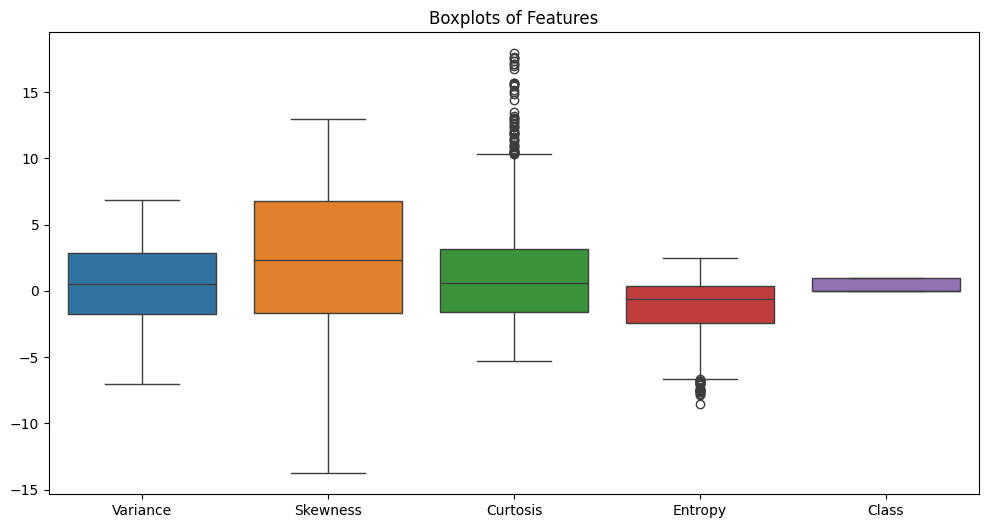

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=dataset)
plt.title("Boxplots of Features")

plt.savefig("Boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

# Task 3: Data Preprocessing

#Normalizing Features

In [12]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   Variance  Skewness  Curtosis   Entropy
0  1.121806  1.149455 -0.975970  0.354561
1  1.447066  1.064453 -0.895036 -0.128767
2  1.207810 -0.777352  0.122218  0.618073
3  1.063742  1.295478 -1.255397 -1.144029
4 -0.036772 -1.087038  0.736730  0.096587


#80/20 split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,         
    y,                 
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Task 4: Perceptron Implementation

#Implementation from scratch

In [14]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    def predict(self, X):

        predictions = []

        for x in X:

            z = np.dot(x, self.weights) + self.bias

            prediction = self.activation(z)

            predictions.append(prediction)

        return np.array(predictions)
    def fit(self, X, y):

        # Convert DataFrame/Series to NumPy arrays if needed
        if hasattr(X, "values"):
            X = X.values

        if hasattr(y, "values"):
            y = y.values

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.error_history = []
        self.weight_history = []
        self.bias_history = []

        for epoch in range(self.epochs):

            errors = 0

            for x, target in zip(X, y):
                z = np.dot(x, self.weights) + self.bias
                prediction = self.activation(z)

                error = target - prediction

                self.weights += self.learning_rate * error * x
                self.bias += self.learning_rate * error

                if error != 0:
                    errors += 1

            self.error_history.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

# Task 5: Model Training

In [15]:
perceptron = Perceptron(learning_rate=0.01, epochs=100)

perceptron.fit(X_train, y_train)

In [16]:
print(type(perceptron.weights))
print(perceptron.weights)
print(perceptron.weights.dtype)

<class 'numpy.ndarray'>
[-0.23381518 -0.26621695 -0.23656786 -0.01854383]
float64


# Task 6: Model Evaluation

In [17]:
y_pred = perceptron.predict(X_test.values)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9855
Precision : 0.9683
Recall    : 1.0000
F1-Score  : 0.9839


#Confusion Matrix

[[149   4]
 [  0 122]]


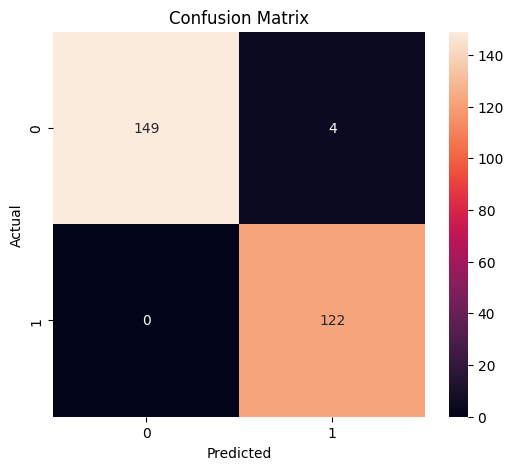

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Mandatory Plots

### Training Error vs Epoch

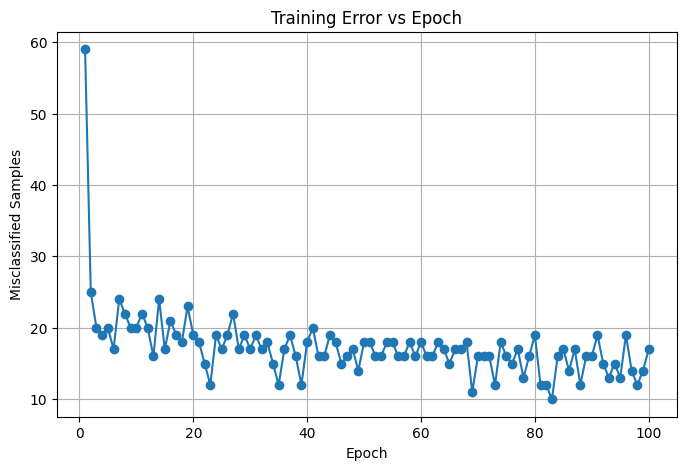

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, perceptron.epochs + 1),
    perceptron.error_history,
    marker='o'
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")

plt.grid(True)

plt.savefig("Training_Error.png", dpi=300, bbox_inches="tight")

plt.show()

### Weight Evolution

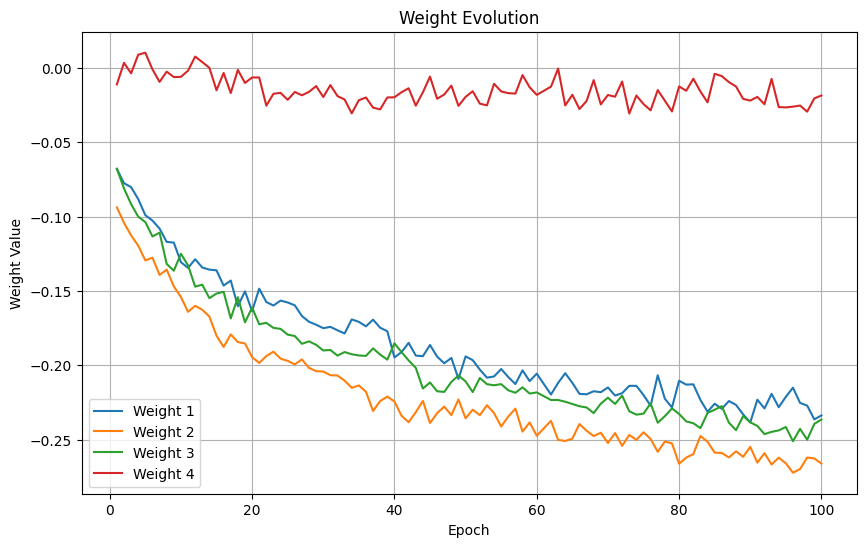

In [20]:
weights = np.array(perceptron.weight_history)

plt.figure(figsize=(10,6))

for i in range(weights.shape[1]):
    plt.plot(
        range(1, perceptron.epochs + 1),
        weights[:, i],
        label=f"Weight {i+1}"
    )

plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")

plt.legend()

plt.grid(True)

plt.savefig("Weight_Evolution.png", dpi=300, bbox_inches="tight")

plt.show()

### Bias Evolution

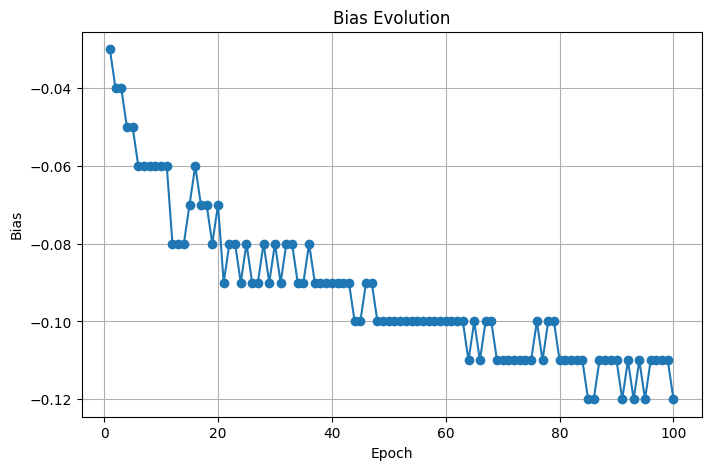

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, perceptron.epochs + 1),
    perceptron.bias_history,
    marker='o'
)

plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.grid(True)

plt.savefig("Bias_Evolution.png", dpi=300, bbox_inches="tight")

plt.show()

### Learning Rate Comparison

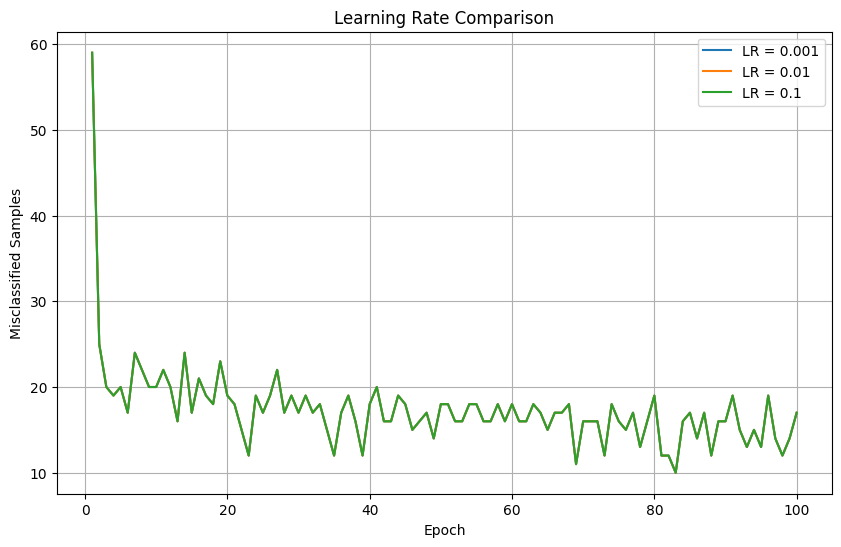

In [22]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(X_train, y_train)

    plt.plot(
        range(1, model.epochs + 1),
        model.error_history,
        label=f"LR = {lr}"
    )

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")

plt.legend()

plt.grid(True)

plt.savefig("Learning_Rate_Comparison.png", dpi=300, bbox_inches="tight")

plt.show()

# OR, NOT, and AND gates implementation using perceptron


Training OR Gate

Epoch 1
---------------------------------------
Input        : [0 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [0. 0.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/OR_update_1.eps


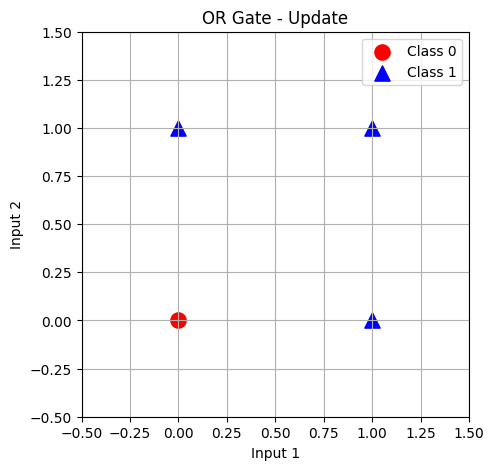

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


---------------------------------------
Input        : [0 1]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [0. 1.]
Bias         : 0
Saved: figures/OR_update_2.eps


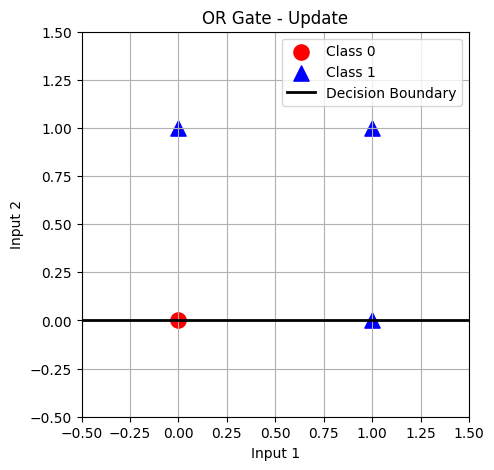


Epoch 2
---------------------------------------
Input        : [0 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [0. 1.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/OR_update_3.eps


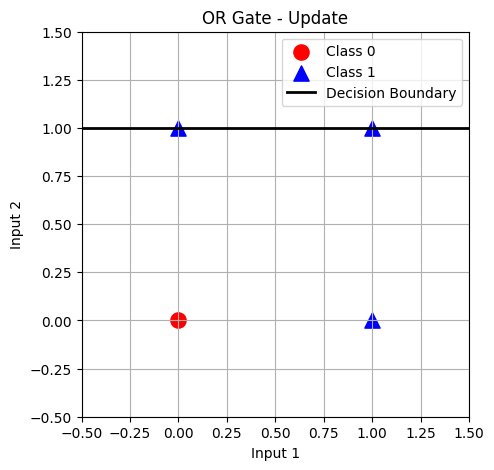

---------------------------------------
Input        : [1 0]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [1. 1.]
Bias         : 0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/OR_update_4.eps


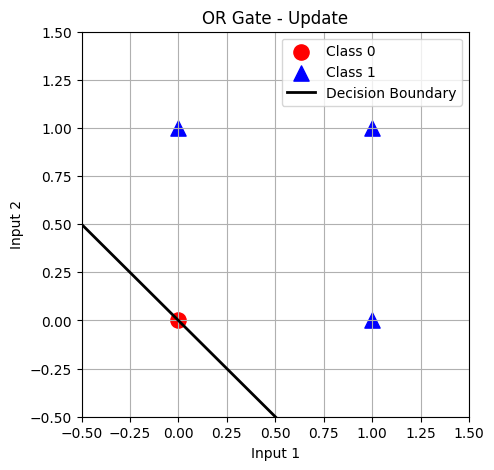


Epoch 3
---------------------------------------
Input        : [0 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [1. 1.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/OR_update_5.eps


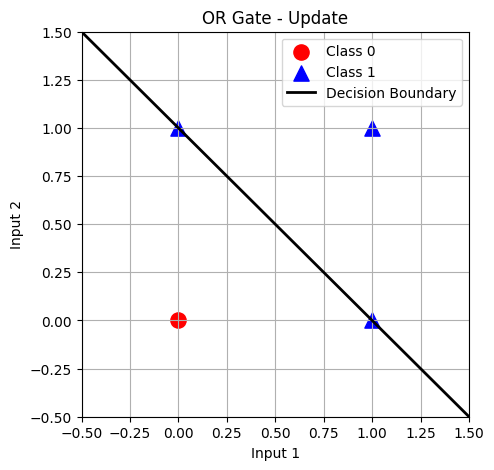


Epoch 4

Training Completed
Final Weights : [1. 1.]
Final Bias    : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/OR_Final_update_6.eps


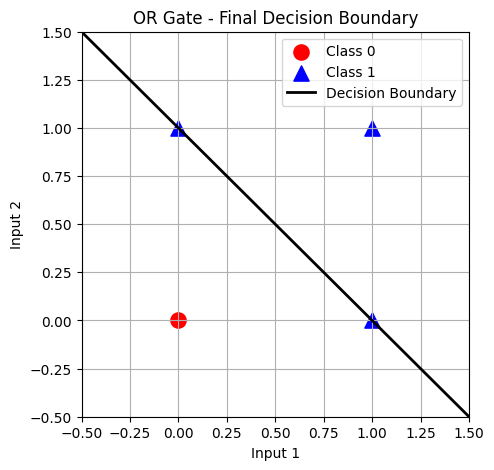


Training AND Gate

Epoch 1
---------------------------------------
Input        : [0 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [0. 0.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_7.eps


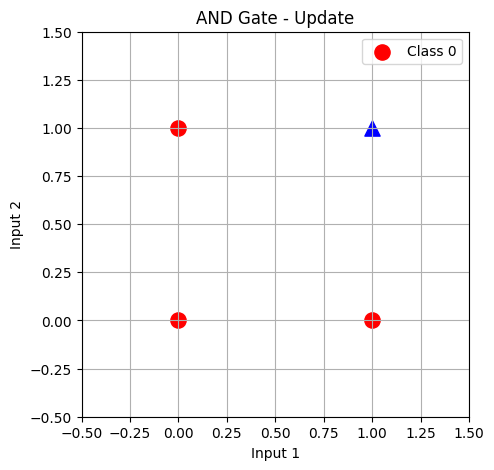

---------------------------------------
Input        : [1 1]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [1. 1.]
Bias         : 0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_8.eps


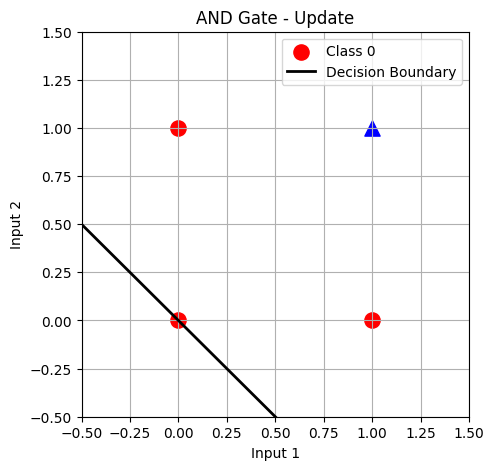


Epoch 2
---------------------------------------
Input        : [0 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [1. 1.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_9.eps


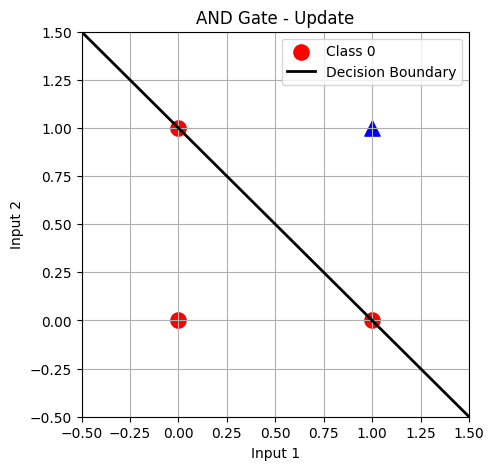

---------------------------------------
Input        : [0 1]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [1. 0.]
Bias         : -2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_10.eps


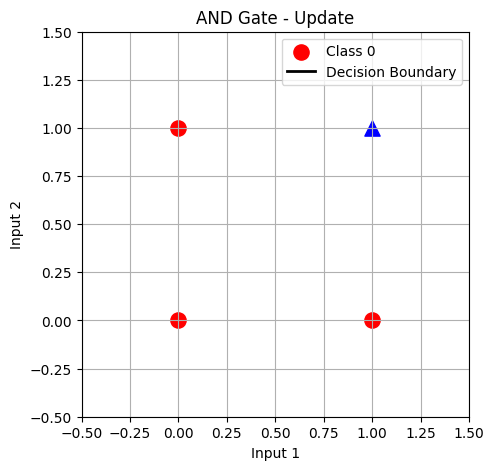

---------------------------------------
Input        : [1 1]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [2. 1.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_11.eps


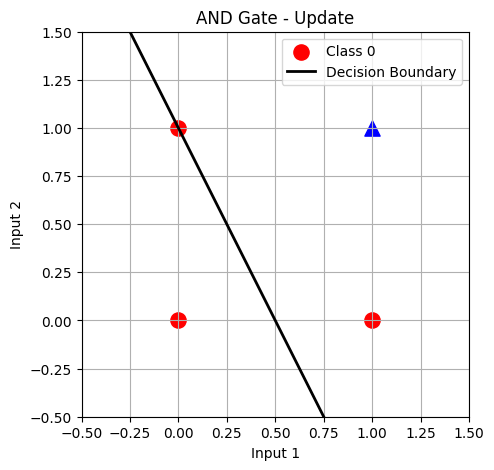


Epoch 3
---------------------------------------
Input        : [0 1]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [2. 0.]
Bias         : -2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_12.eps


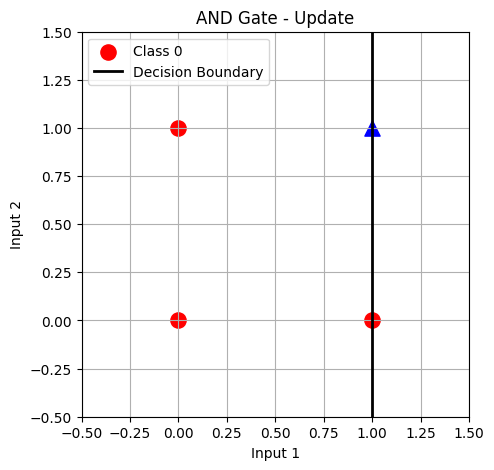

---------------------------------------
Input        : [1 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [1. 0.]
Bias         : -3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_13.eps


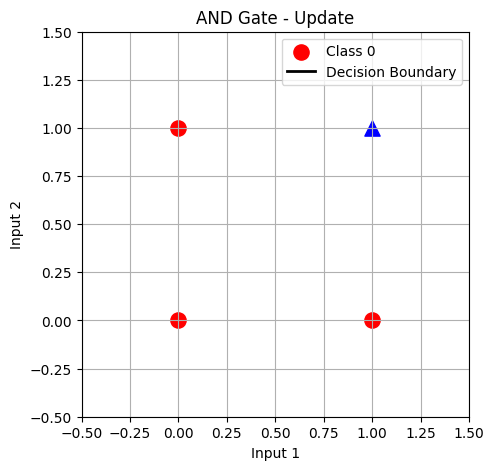

---------------------------------------
Input        : [1 1]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [2. 1.]
Bias         : -2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_14.eps


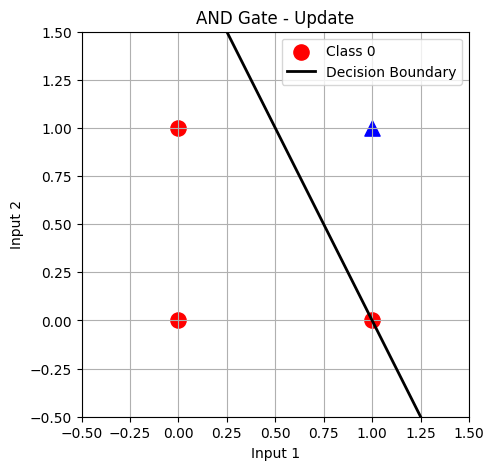


Epoch 4
---------------------------------------
Input        : [1 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [1. 1.]
Bias         : -3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_15.eps


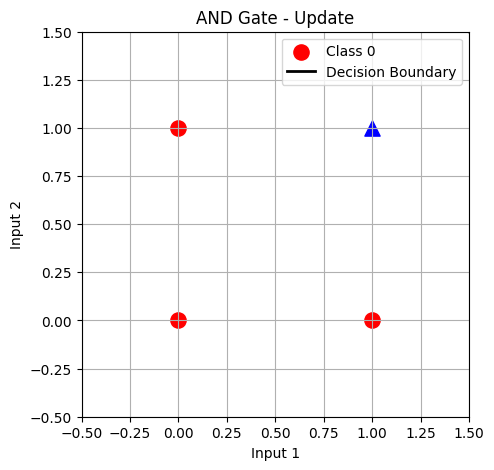

---------------------------------------
Input        : [1 1]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [2. 2.]
Bias         : -2


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_16.eps


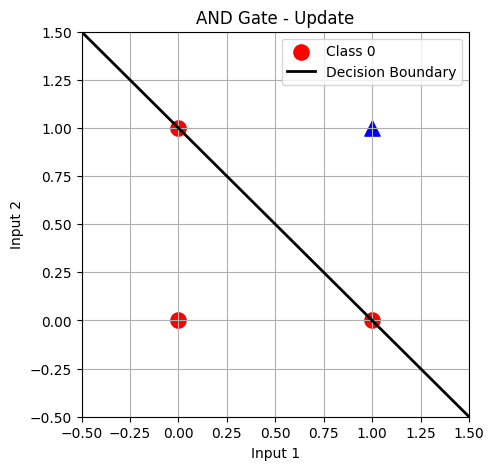


Epoch 5
---------------------------------------
Input        : [0 1]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [2. 1.]
Bias         : -3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_update_17.eps


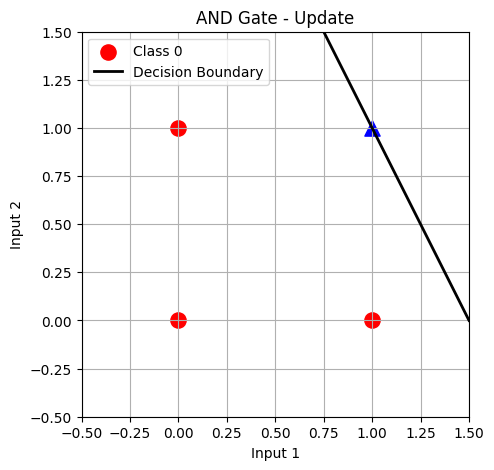


Epoch 6

Training Completed
Final Weights : [2. 1.]
Final Bias    : -3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/AND_Final_update_18.eps


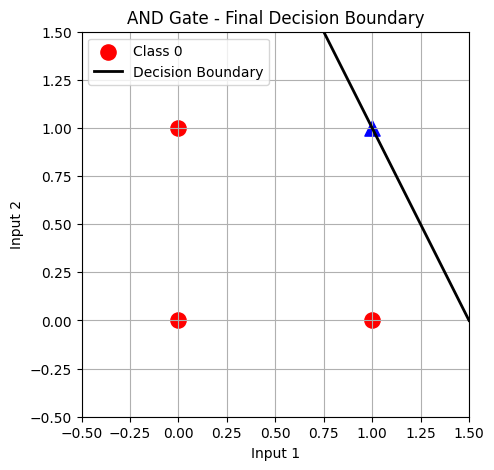


Training NOT Gate

Epoch 1
---------------------------------------
Input        : [1 0]
Target       : 0
Predicted    : 1
Error        : -1
Weights      : [-1.  0.]
Bias         : -1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/NOT_update_19.eps


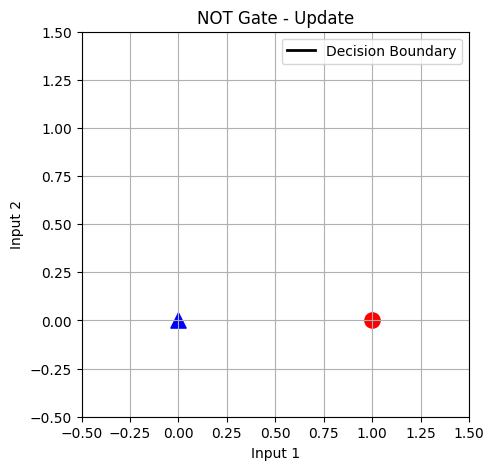


Epoch 2
---------------------------------------
Input        : [0 0]
Target       : 1
Predicted    : 0
Error        : 1
Weights      : [-1.  0.]
Bias         : 0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/NOT_update_20.eps


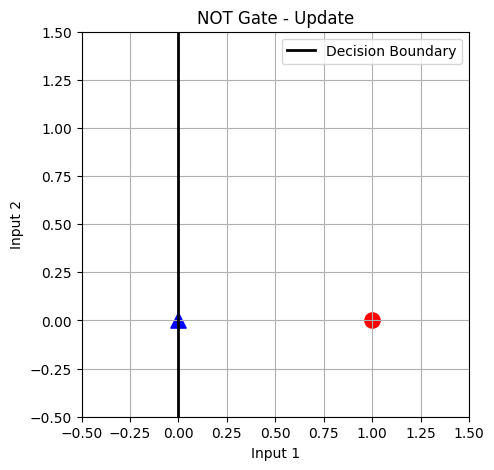


Epoch 3

Training Completed
Final Weights : [-1.  0.]
Final Bias    : 0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: figures/NOT_Final_update_21.eps


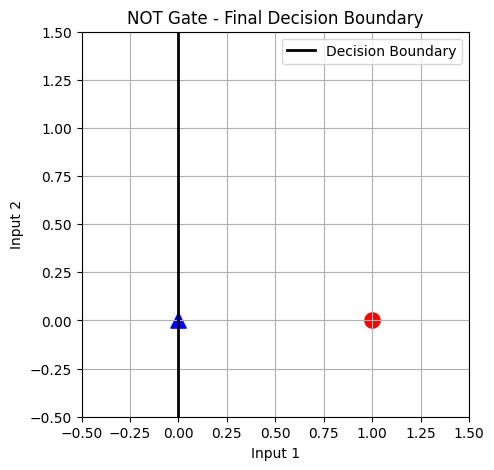


All figures have been saved in:
figures/


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Create folder for saving figures
# ==========================================================
os.makedirs("figures", exist_ok=True)

learning_rate = 1
plot_count = 1


# ==========================================================
# Function to plot and save decision boundary
# ==========================================================
def plot_decision_boundary(X, y, weights, bias, title, gate):
    global plot_count

    plt.figure(figsize=(5, 5))

    # Plot points
    for i in range(len(y)):
        if y[i] == 0:
            plt.scatter(
                X[i][0],
                X[i][1],
                color="red",
                marker="o",
                s=120,
                label="Class 0" if i == 0 else ""
            )
        else:
            plt.scatter(
                X[i][0],
                X[i][1],
                color="blue",
                marker="^",
                s=120,
                label="Class 1" if i == 1 else ""
            )

    # Decision boundary
    x = np.linspace(-0.5, 1.5, 100)

    if abs(weights[1]) > 1e-6:
        y_line = -(weights[0] * x + bias) / weights[1]
        plt.plot(x, y_line, color="black", linewidth=2,
                 label="Decision Boundary")

    elif abs(weights[0]) > 1e-6:
        plt.axvline(
            x=-bias / weights[0],
            color="black",
            linewidth=2,
            label="Decision Boundary"
        )

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)

    plt.grid(True)
    plt.legend()

    filename = f"figures/{gate}_update_{plot_count}.eps"

    plt.savefig(
        filename,
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    print("Saved:", filename)

    plot_count += 1

    plt.show()
    plt.close()


# ==========================================================
# Perceptron Training
# ==========================================================
def train_perceptron(X, y, gate):

    weights = np.zeros(2)
    bias = 0

    epoch = 1

    print("\n==============================")
    print(f"Training {gate} Gate")
    print("==============================")

    while True:

        error_count = 0

        print(f"\nEpoch {epoch}")

        for i in range(len(X)):

            net = np.dot(X[i], weights) + bias

            if net >= 0:
                output = 1
            else:
                output = 0

            error = y[i] - output

            if error != 0:

                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error

                print("---------------------------------------")
                print("Input        :", X[i])
                print("Target       :", y[i])
                print("Predicted    :", output)
                print("Error        :", error)
                print("Weights      :", weights)
                print("Bias         :", bias)

                plot_decision_boundary(
                    X,
                    y,
                    weights,
                    bias,
                    f"{gate} Gate - Update",
                    gate
                )

                error_count += 1

        if error_count == 0:
            break

        epoch += 1

    print("\nTraining Completed")
    print("Final Weights :", weights)
    print("Final Bias    :", bias)

    plot_decision_boundary(
        X,
        y,
        weights,
        bias,
        f"{gate} Gate - Final Decision Boundary",
        gate + "_Final"
    )


# ==========================================================
# OR Gate
# ==========================================================
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([
    0,
    1,
    1,
    1
])

train_perceptron(X_or, y_or, "OR")


# ==========================================================
# AND Gate
# ==========================================================
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([
    0,
    0,
    0,
    1
])

train_perceptron(X_and, y_and, "AND")


# ==========================================================
# NOT Gate
# ==========================================================
X_not = np.array([
    [0, 0],
    [1, 0]
])

y_not = np.array([
    1,
    0
])

train_perceptron(X_not, y_not, "NOT")

print("\n======================================")
print("All figures have been saved in:")
print("figures/")
print("======================================")